# Seasonal Agriculture Performance Analysis


**Dataset:** `seasonal_agriculture_raw.csv` — 4,000 farm records across 3 crop seasons (Kharif, Rabi, Zaid), 8 crops, 8 states, 4 irrigation methods.

**Problem statement:** Agricultural performance is known to vary across seasons, but raw farm-level data doesn't make it obvious *how much* it varies, *for whom*, or *why*. This notebook explores the dataset season-by-season to find real, defensible patterns — not just a description of the columns.

**How this notebook is organized:**
1. Load & inspect the data
2. Data quality checks and cleaning
3. Season-level exploration (environmental conditions)
4. Key Question — does yield really vary by season, or is that just crop mix?
5. Key Question — does profit follow the same pattern, and how many farms are actually losing money?
6. Key Question — what's driving the differences (weather? cost? water?)
7. Irrigation efficiency across seasons
8. Conclusions


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 10,
})
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#4C72B0', 'Rabi': '#DD8452', 'Zaid': '#C44E52'}

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


## 1. To Load & inspect the data

In [ ]:
df = pd.read_csv('seasonal_agriculture_raw.csv')
print(df.shape)
df.head()


(4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


One thing jumps out immediately in `describe()`: **`Yield_Tonnes_Ha`** has a mean of ~5.3 but a max of over 100, while the 75th percentile is only 2.84. That's a huge skew — worth checking before we trust any "average yield" number.

In [ ]:
df.nlargest(10, 'Yield_Tonnes_Ha')[['Farm_ID','Crop','Season','Yield_Tonnes_Ha','Production_Tonnes']]

,Farm_ID,Crop,Season,Yield_Tonnes_Ha,Production_Tonnes
1715,SF11716,Sugarcane,Kharif,101.44,641.10
3423,SF13424,Sugarcane,Kharif,95.79,1424.40
3525,SF13526,Sugarcane,Rabi,93.13,648.18
1464,SF11465,Sugarcane,Kharif,91.98,703.65
3523,SF13524,Sugarcane,Kharif,91.46,75.00
2782,SF12783,Sugarcane,Rabi,91.32,522.35
644,SF10645,Sugarcane,Kharif,89.34,668.26
2847,SF12848,Sugarcane,Kharif,87.76,672.24
357,SF10358,Sugarcane,Rabi,84.75,1249.21
1178,SF11179,Sugarcane,Kharif,83.79,534.58


Good — the high-yield outliers are **all Sugarcane**, and real-world sugarcane genuinely yields 60–100+ tonnes/hectare (it's harvested as whole cane, not grain), so this isn't a data error. It does mean, though, that **any analysis pooling yield across crops will be dominated by Sugarcane** and will misrepresent every other crop. We'll analyze yield per-crop rather than pooled wherever it matters.

## 2. Data quality checks

Checking for missing values, duplicates, and whether the geographic fields (State/District) are internally consistent.

In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate Farm_ID:", df['Farm_ID'].duplicated().sum())


Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Fully duplicated rows: 0
Duplicate Farm_ID: 0


In [ ]:
# Check whether District is a real sub-region of State, or randomly assigned
state_district = df.groupby('State')['District'].unique()
for s, ds in state_district.items():
    print(f"{s:16s} -> {list(ds)}")


Andhra Pradesh   -> ['Rajkot', 'Warangal', 'Raichur', 'Nalgonda', 'Guntur', 'Ludhiana', 'Erode', 'Nashik', 'Indore', 'Krishna']
Gujarat          -> ['Raichur', 'Indore', 'Erode', 'Ludhiana', 'Guntur', 'Warangal', 'Krishna', 'Rajkot', 'Nashik', 'Nalgonda']
Karnataka        -> ['Ludhiana', 'Guntur', 'Indore', 'Krishna', 'Warangal', 'Nashik', 'Erode', 'Raichur', 'Nalgonda', 'Rajkot']
Madhya Pradesh   -> ['Krishna', 'Indore', 'Ludhiana', 'Erode', 'Raichur', 'Nalgonda', 'Warangal', 'Guntur', 'Rajkot', 'Nashik']
Maharashtra      -> ['Nalgonda', 'Krishna', 'Ludhiana', 'Erode', 'Rajkot', 'Guntur', 'Indore', 'Raichur', 'Nashik', 'Warangal']
Punjab           -> ['Indore', 'Nalgonda', 'Ludhiana', 'Krishna', 'Rajkot', 'Nashik', 'Erode', 'Guntur', 'Warangal', 'Raichur']
Tamil Nadu       -> ['Ludhiana', 'Raichur', 'Rajkot', 'Nalgonda', 'Erode', 'Warangal', 'Krishna', 'Guntur', 'Nashik', 'Indore']
Telangana        -> ['Warangal', 'Indore', 'Rajkot', 'Nashik', 'Nalgonda', 'Erode', 'Guntur', 'Krishna',

Every district shows up under multiple, unrelated states (e.g. "Rajkot" — actually a city in Gujarat — appears under Andhra Pradesh, Gujarat, Maharashtra, Punjab, Tamil Nadu and Telangana). State and District were clearly generated independently of each other.

**Decision:** we drop `District` from any geographic analysis and don't treat `State` as a reliable location signal either, since we can't verify it's consistent. This notebook focuses on **Season and Crop**, which are clean, checked categorical fields.

In [ ]:
# Missing value handling
# Rainfall_mm and Soil_Moisture_pct are input/environmental readings -> impute with the
# median for that Season (small number of nulls, <1.2% of rows each)
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Yield_Tonnes_Ha is our key OUTCOME variable - imputing a target variable can quietly bias
# results, so instead we just leave those 32 rows as NaN and let pandas/scipy skip them
# in yield-specific calculations (they're still used for every other column).
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Remaining missing values:
Yield_Tonnes_Ha    32
dtype: int64


## 3. Season-level exploration

India's three cropping seasons have very different growing conditions by definition — Kharif is the monsoon season, Rabi is the cool dry season, Zaid is the short hot summer season. Let's confirm that's actually reflected in this dataset before assuming it explains anything.

In [ ]:
season_summary = df.groupby('Season').agg(
    n_farms=('Farm_ID', 'count'),
    Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temp_C=('Avg_Temperature_C', 'mean'),
    Humidity_pct=('Humidity_pct', 'mean'),
    Soil_Moisture_pct=('Soil_Moisture_pct', 'mean'),
).round(1).reindex(SEASON_ORDER)
season_summary


,n_farms,Rainfall_mm,Avg_Temp_C,Humidity_pct,Soil_Moisture_pct
Season,,,,,
Kharif,1779,852.1,28.5,71.8,31.2
Rabi,1627,435.9,23.5,57.9,24.1
Zaid,594,299.1,31.0,52.0,19.2


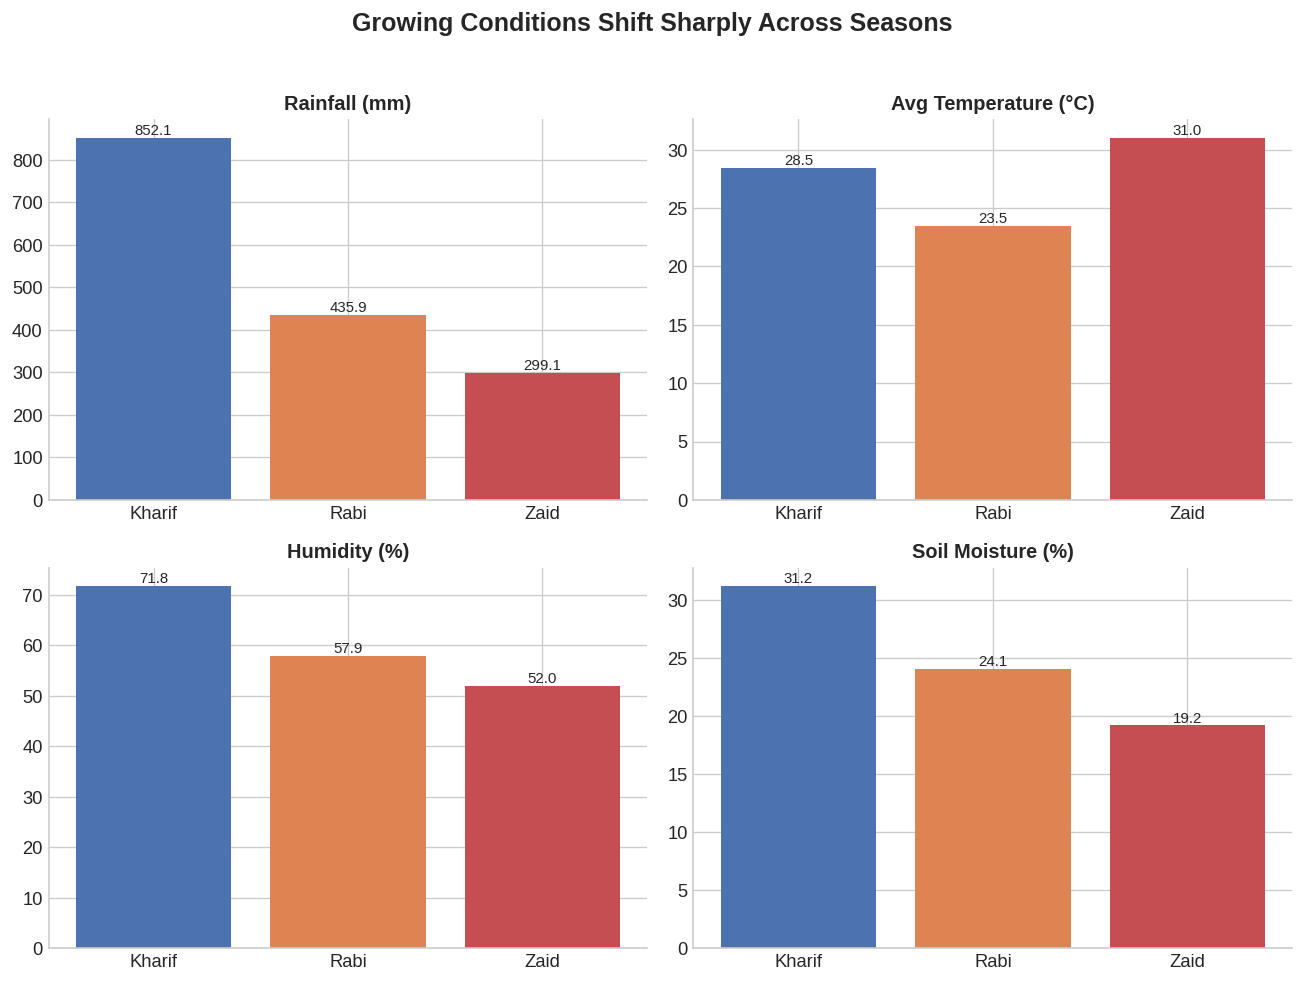

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
metrics = [('Rainfall_mm', 'Rainfall (mm)'), ('Avg_Temperature_C', 'Avg Temperature (°C)'),
           ('Humidity_pct', 'Humidity (%)'), ('Soil_Moisture_pct', 'Soil Moisture (%)')]
for ax, (col, label) in zip(axes.flat, metrics):
    vals = df.groupby('Season')[col].mean().reindex(SEASON_ORDER)
    bars = ax.bar(vals.index, vals.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{b.get_height():.1f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('Growing Conditions Shift Sharply Across Seasons', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/03_environmental_profile.png', dpi=150, bbox_inches='tight')
plt.show()


That matches expectations: Kharif is wet and humid (852mm rainfall, 72% humidity), Rabi is cooler and drier, and Zaid is hot and dry (only 299mm rainfall, lowest soil moisture at 19%). The dataset's seasonal labels are internally consistent with real agro-climatic definitions, which gives some confidence in the rest of the data.

## 4. Key Question — Does yield actually vary by season?

Since Sugarcane's absolute yield scale would swamp everything else, we look at each crop **separately**, using the **median** (robust to outliers) rather than the mean.

In [ ]:
yield_pivot = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='median')[SEASON_ORDER].round(2)
yield_pivot


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.78,1.56,1.22
Cotton,1.44,1.20,0.97
Groundnut,1.52,1.29,1.10
Maize,3.12,2.82,2.27
Pulses,1.09,0.90,0.66
Rice,2.88,2.38,1.94
Sugarcane,56.65,45.46,38.78
Wheat,2.36,2.22,1.84


In [ ]:
# Statistical test: for each crop, is the difference in yield across seasons real,
# or could it just be noise? Kruskal-Wallis (non-parametric ANOVA) since yield isn't normally distributed.
print(f"{'Crop':12s} {'H-stat':>8s} {'p-value':>10s}  Result")
for crop in df['Crop'].unique():
    sub = df[df['Crop'] == crop]
    groups = [sub[sub['Season'] == s]['Yield_Tonnes_Ha'].dropna() for s in SEASON_ORDER]
    h, p = stats.kruskal(*groups)
    verdict = 'significant (p<0.05)' if p < 0.05 else 'not significant'
    print(f"{crop:12s} {h:8.2f} {p:10.4f}  {verdict}")


Crop           H-stat    p-value  Result
Wheat           22.75     0.0000  significant (p<0.05)
Maize           22.50     0.0000  significant (p<0.05)
Pulses          44.69     0.0000  significant (p<0.05)
Rice            46.22     0.0000  significant (p<0.05)
Cotton          43.06     0.0000  significant (p<0.05)
Chilli          26.26     0.0000  significant (p<0.05)
Groundnut       30.07     0.0000  significant (p<0.05)
Sugarcane       26.07     0.0000  significant (p<0.05)


**Every single crop** shows a statistically significant difference in yield across seasons. That's not a coincidence of one or two crops — it's a dataset-wide pattern. To see the *shape* of that pattern clearly despite the very different absolute scales (Sugarcane's ~50 t/ha vs Pulses' ~1 t/ha), we index each crop's own Kharif yield to 100 and compare relative drops.

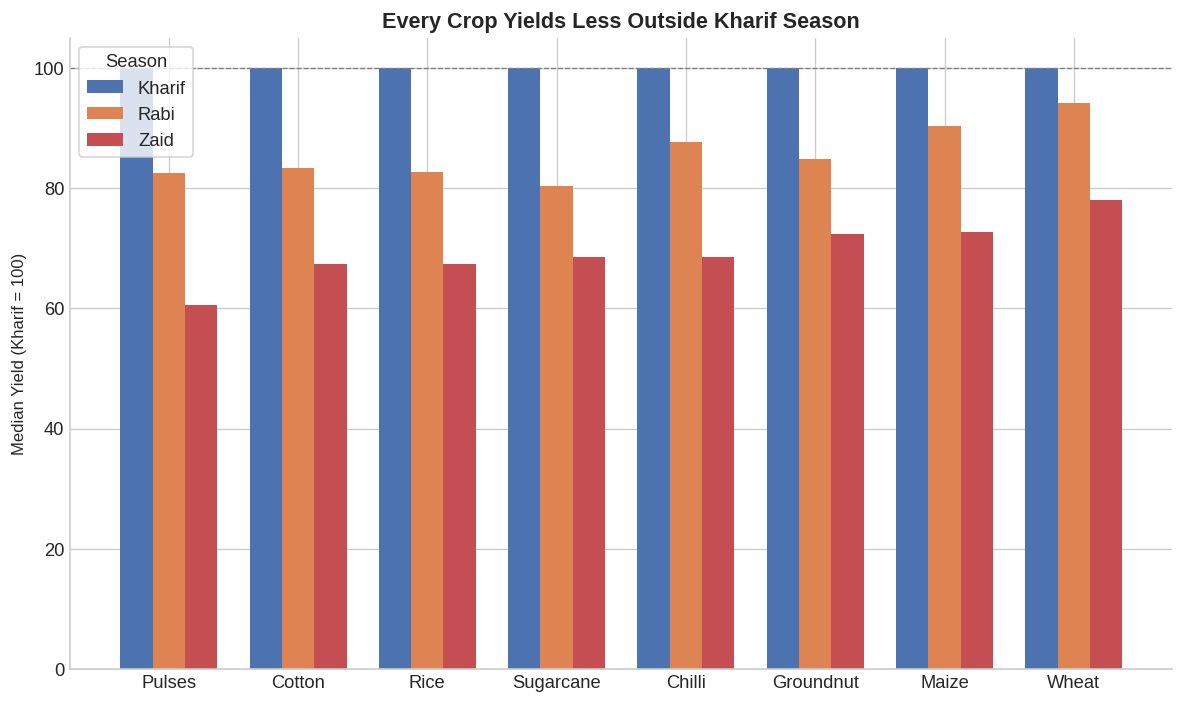

In [ ]:
idx = yield_pivot.div(yield_pivot['Kharif'], axis=0) * 100
idx = idx.sort_values('Zaid')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(idx)); w = 0.25
for i, s in enumerate(SEASON_ORDER):
    ax.bar(x + (i-1)*w, idx[s], width=w, label=s, color=SEASON_COLORS[s])
ax.axhline(100, color='grey', linewidth=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels(idx.index)
ax.set_ylabel('Median Yield (Kharif = 100)')
ax.set_title('Every Crop Yields Less Outside Kharif Season', fontweight='bold')
ax.legend(title='Season', frameon=True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/01_yield_index_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** Kharif is the best-yielding season for every crop in this dataset, without exception. Zaid is worst for every crop, with yield dropping to 60-78% of the Kharif baseline depending on crop. Pulses is hit hardest (drops to ~60%); Wheat holds up best (~78%).

## 5. Key Question — Does profit follow the same seasonal pattern?

Yield is only half the economic picture — cost and price matter too. We check profit the same way: per-crop, using medians.

In [ ]:
profit_pivot = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='median')[SEASON_ORDER].round(0)
profit_pivot


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,705116.0,470004.0,350401.0
Cotton,136193.0,50603.0,-11434.0
Groundnut,87406.0,24517.0,-38896.0
Maize,-9884.0,-45813.0,-147456.0
Pulses,57156.0,-11734.0,-128893.0
Rice,-39904.0,-49932.0,-183632.0
Sugarcane,940895.0,622229.0,556627.0
Wheat,-57248.0,-76084.0,-125778.0


A few things stand out here that *aren't* purely about season:
- **Chilli and Sugarcane stay profitable in every season** — these look like structurally strong cash crops in this dataset.
- **Wheat, Maize, Rice run a median loss in almost every season**, Kharif included. For these crops, season isn't the main problem — the underlying cost/price economics are.

So profitability depends on *both* season and crop choice, not season alone. Let's confirm the seasonal effect statistically, the same way we did for yield.

In [ ]:
print(f"{'Crop':12s} {'H-stat':>8s} {'p-value':>10s}  Result")
for crop in df['Crop'].unique():
    sub = df[df['Crop'] == crop]
    groups = [sub[sub['Season'] == s]['Profit_INR'].dropna() for s in SEASON_ORDER]
    h, p = stats.kruskal(*groups)
    verdict = 'significant (p<0.05)' if p < 0.05 else 'not significant'
    print(f"{crop:12s} {h:8.2f} {p:10.4f}  {verdict}")


Crop           H-stat    p-value  Result
Wheat           15.68     0.0004  significant (p<0.05)
Maize           28.62     0.0000  significant (p<0.05)
Pulses          30.00     0.0000  significant (p<0.05)
Rice            36.21     0.0000  significant (p<0.05)
Cotton          35.39     0.0000  significant (p<0.05)
Chilli          13.88     0.0010  significant (p<0.05)
Groundnut       22.36     0.0000  significant (p<0.05)
Sugarcane       11.80     0.0027  significant (p<0.05)


Significant for every crop again. Now let's look at it from the farmer's-eye view: what share of farms are actually operating at a loss each season?

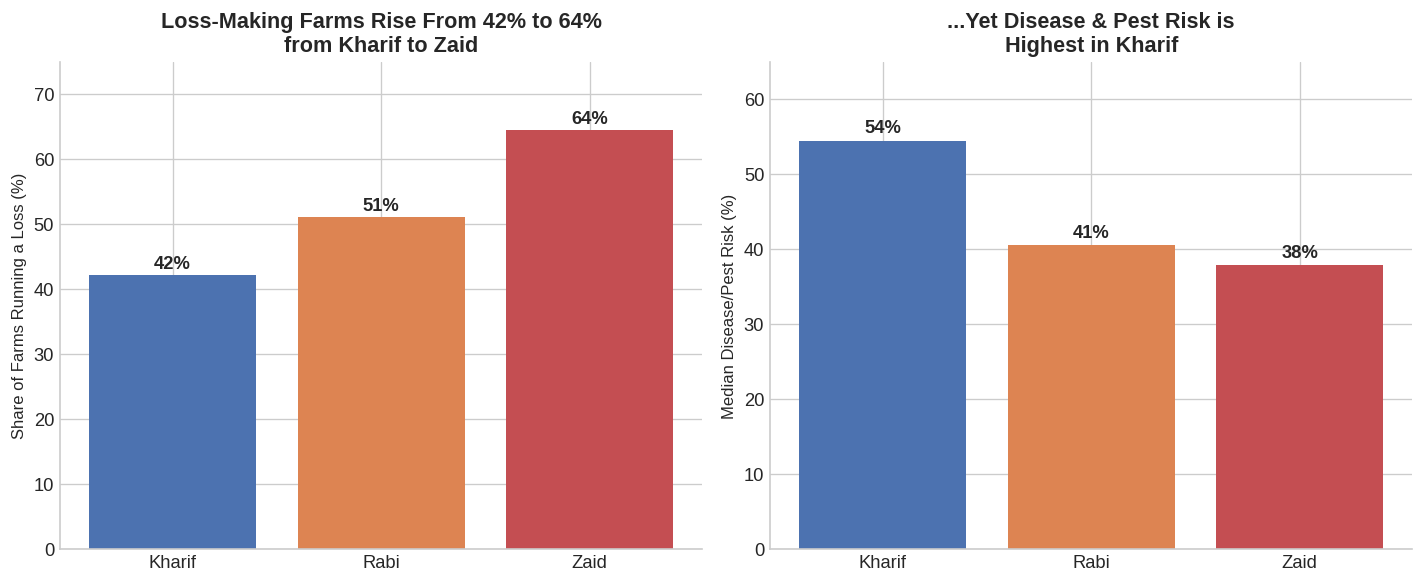

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

loss = df.groupby('Season')['Profit_INR'].apply(lambda x: (x < 0).mean() * 100).reindex(SEASON_ORDER)
bars = axes[0].bar(loss.index, loss.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.0f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('Share of Farms Running a Loss (%)')
axes[0].set_title('Loss-Making Farms Rise From 42% to 64%\nfrom Kharif to Zaid', fontweight='bold')
axes[0].set_ylim(0, 75)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

disease = df.groupby('Season')['Disease_Pest_Risk_pct'].median().reindex(SEASON_ORDER)
bars2 = axes[1].bar(disease.index, disease.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{b.get_height():.0f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('Median Disease/Pest Risk (%)')
axes[1].set_title('...Yet Disease & Pest Risk is\nHighest in Kharif', fontweight='bold')
axes[1].set_ylim(0, 65)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/02_lossrate_diseaserisk.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** 42% of farms lose money even in the "good" Kharif season, rising to 51% in Rabi and 64% in Zaid. Losses are common in this dataset generally, but Zaid is meaningfully riskier.

Interesting wrinkle: disease/pest risk is actually *highest* in Kharif (54%), not lowest — despite Kharif having the best yield and profit outcomes. We'll come back to why in the correlation section below.

## 6. Key Question — What's actually driving the seasonal difference?

Is it rainfall? Temperature? Cost? Let's check correlations, and also directly compare cost/water use against output by season.

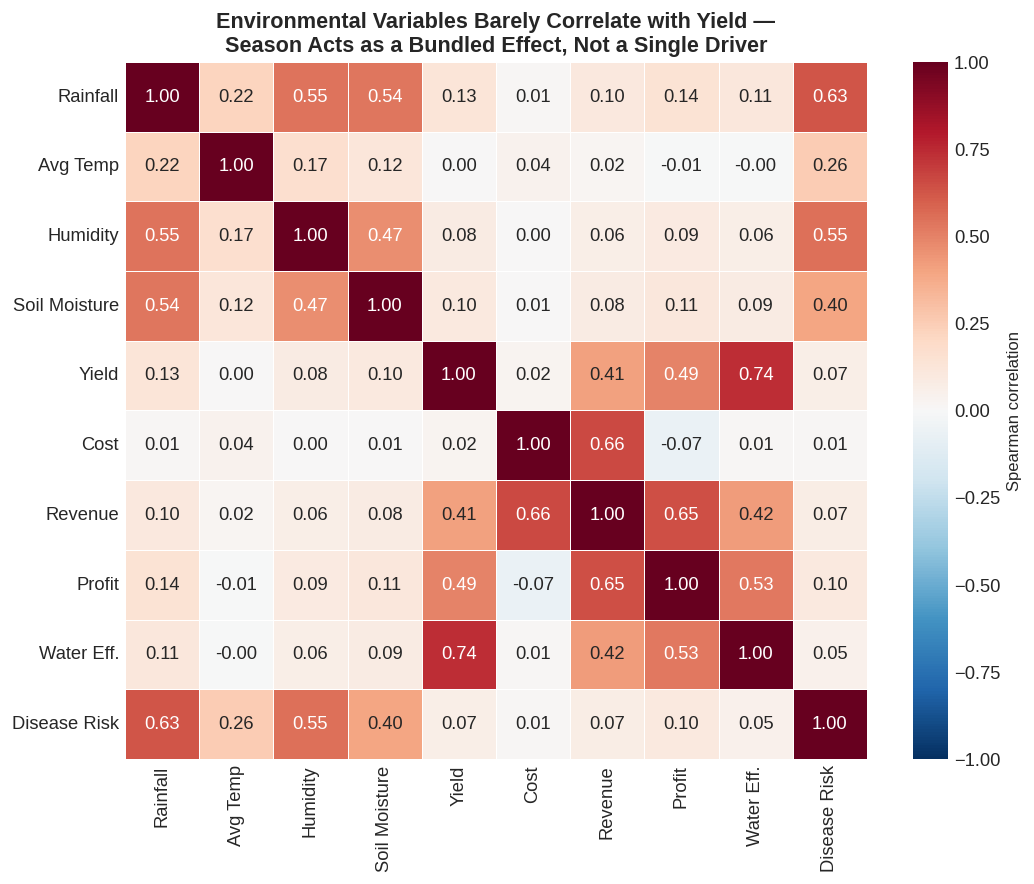

In [ ]:
cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
        'Yield_Tonnes_Ha','Total_Cost_INR','Revenue_INR','Profit_INR',
        'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
labels = ['Rainfall','Avg Temp','Humidity','Soil Moisture','Yield','Cost','Revenue','Profit','Water Eff.','Disease Risk']
corr = df[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Spearman correlation'})
ax.set_title('Environmental Variables Barely Correlate with Yield —\nSeason Acts as a Bundled Effect, Not a Single Driver', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('charts/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Two things worth calling out:

1. **Rainfall and Humidity correlate with Disease/Pest Risk (0.63 and 0.55)** — this explains the Kharif paradox from the previous section. The same monsoon conditions that make Kharif the highest-yielding season also raise disease and pest pressure. Kharif's yield/profit advantage evidently outweighs that extra risk, but it isn't a free lunch.
2. **No single environmental variable (rainfall, temperature, soil moisture) correlates strongly with yield** (all under 0.15) when you look at farm-to-farm variation *within* a season. That doesn't contradict the seasonal pattern we found earlier — it means the season effect isn't reducible to "more rainfall = more yield" in a simple linear way across individual farms. It's more likely a bundled effect: season determines crop suitability, pest cycles, typical practices, etc. all at once, and no single weather column captures that on its own in this dataset.

(Yield and Water Efficiency show 0.74 correlation, but that's mechanical — Water Efficiency is literally defined as tonnes yielded per 1000m³ of water used, so it's not an independent confirmation.)

Next, is Zaid actually cheaper to farm (less water, less cost) even though it yields less — or is it worse on every count?

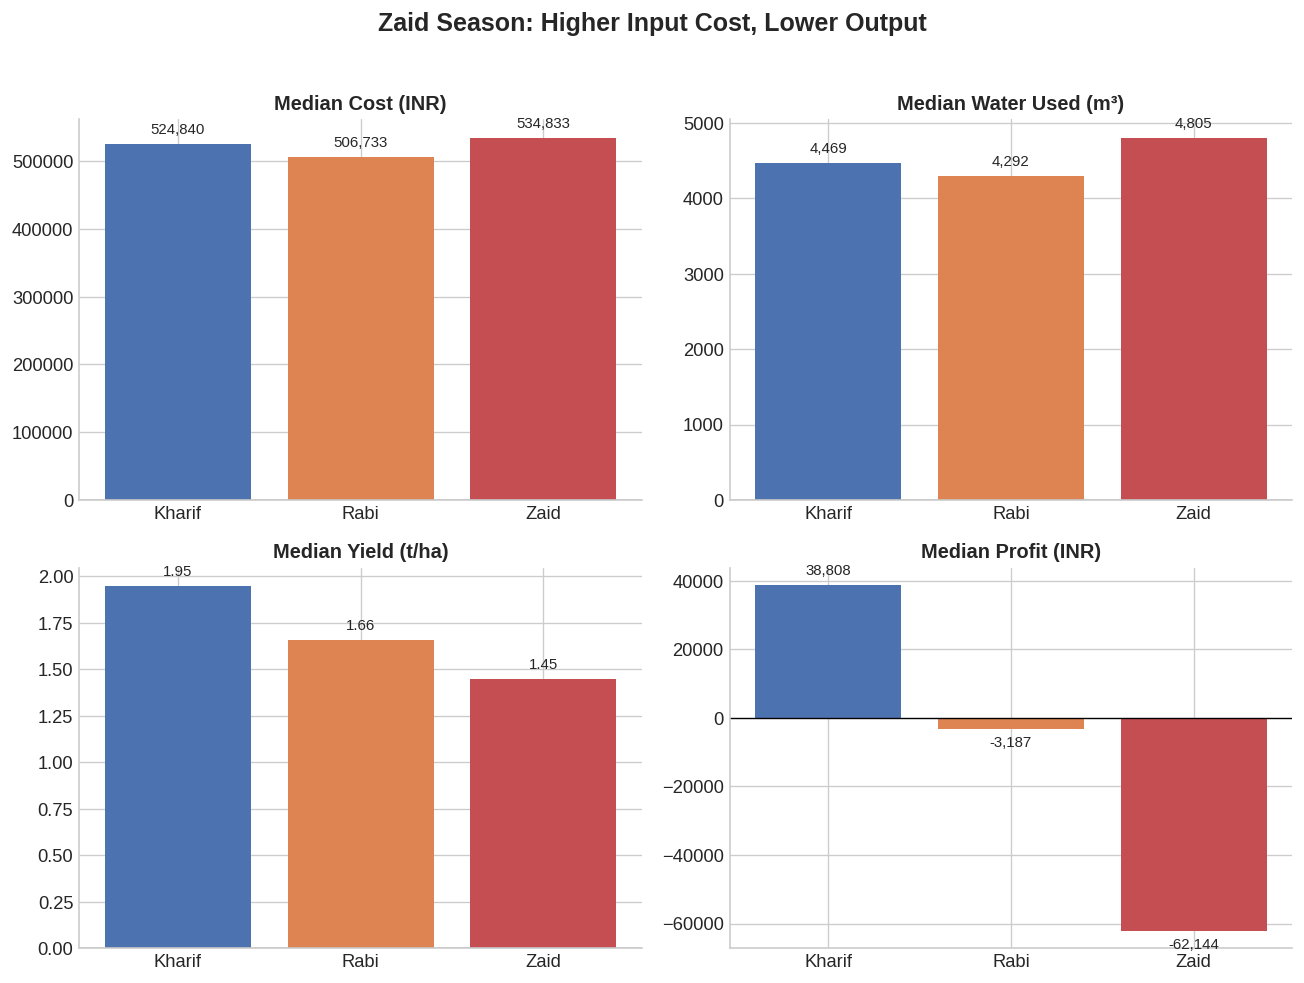

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
specs = [('Total_Cost_INR', 'Median Cost (INR)', '{:,.0f}'), ('Water_Used_m3', 'Median Water Used (m³)', '{:,.0f}'),
         ('Yield_Tonnes_Ha', 'Median Yield (t/ha)', '{:.2f}'), ('Profit_INR', 'Median Profit (INR)', '{:,.0f}')]
for ax, (col, label, fmt) in zip(axes.flat, specs):
    vals = df.groupby('Season')[col].median().reindex(SEASON_ORDER)
    bars = ax.bar(vals.index, vals.values, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=12)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    yr = vals.max() - min(vals.min(), 0)
    for b in bars:
        va = 'bottom' if b.get_height() >= 0 else 'top'
        offset = yr*0.02 if b.get_height() >= 0 else -yr*0.02
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+offset, fmt.format(b.get_height()), ha='center', va=va, fontsize=9)
fig.suptitle('Zaid Season: Higher Input Cost, Lower Output', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/04_cost_water_vs_output.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print("Median market price by season (INR/tonne):")
print(df.groupby('Season')['Market_Price_INR_Tonne'].median().reindex(SEASON_ORDER))


Median market price by season (INR/tonne):
Season
Kharif    25793.0
Rabi      26041.0
Zaid      25749.5
Name: Market_Price_INR_Tonne, dtype: float64


**Finding:** Zaid is genuinely the worst deal — it has the *highest* median cost (₹534,833) and *highest* water use (4,805 m³), while producing the *lowest* yield and the only negative median profit. Market price doesn't compensate either — it's essentially flat across all three seasons (~₹25,700-26,000/tonne). Farmers aren't getting a better price for a smaller Zaid harvest; they're just getting less for more input, likely because Zaid crops rely more heavily on irrigation to substitute for the missing monsoon rainfall.

## 7. Irrigation efficiency across seasons

Since Zaid leans more on irrigation, does the *choice* of irrigation method matter?

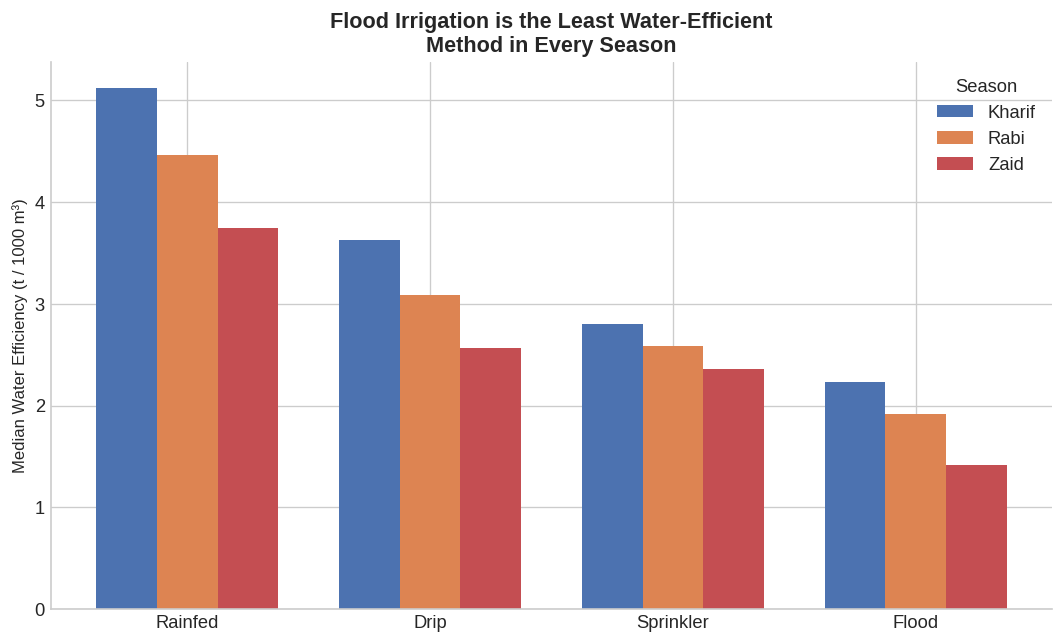

In [ ]:
irr_pivot = df.pivot_table(index='Irrigation_Method', columns='Season',
                            values='Water_Efficiency_t_per_1000m3', aggfunc='median')[SEASON_ORDER]
irr_pivot = irr_pivot.sort_values('Kharif', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(irr_pivot)); w = 0.25
for i, s in enumerate(SEASON_ORDER):
    ax.bar(x + (i-1)*w, irr_pivot[s], width=w, label=s, color=SEASON_COLORS[s])
ax.set_xticks(x); ax.set_xticklabels(irr_pivot.index)
ax.set_ylabel('Median Water Efficiency (t / 1000 m³)')
ax.set_title('Flood Irrigation is the Least Water-Efficient\nMethod in Every Season', fontweight='bold')
ax.legend(title='Season')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/05_irrigation_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


**Finding:** the ranking (Rainfed > Drip > Sprinkler > Flood) holds in every single season. Flood is consistently the least water-efficient method — this matters more in Zaid, where water is scarcer and every farm is leaning harder on irrigation. Farms currently using Flood irrigation in Zaid season look like the clearest, most actionable improvement opportunity in the dataset.

(Rainfed shows the highest "efficiency" partly because it isn't drawing from an active irrigation source in the same way, so this number isn't perfectly apples-to-apples with the other three — but among the three *active* irrigation methods, Drip is clearly the best performer.)

## 8. Conclusions & recommendations

**What I found:**

1. **Kharif is the strongest season for both yield and profit, for every single crop in the dataset** (statistically significant, p<0.05 in every case). Zaid is the weakest, also without exception.
2. **The risk of running a loss climbs sharply across the season calendar** — 42% of farms in Kharif, 51% in Rabi, 64% in Zaid.
3. **Zaid isn't a simple "lower yield, lower cost" trade-off — it's worse on every dimension**: highest median cost, highest water use, lowest yield, only season with a negative median profit. Market prices don't compensate for the shortfall.
4. **Crop choice matters as much as season.** Chilli and Sugarcane stay profitable across all three seasons; Wheat, Maize and Rice run median losses in most or all seasons regardless of season. A full risk picture needs season *and* crop together, not season alone.
5. **No single weather variable explains yield at the individual-farm level** — season looks like a bundled effect (crop suitability, practices, pest cycles together) rather than something reducible to rainfall or temperature alone.
6. **Kharif's rainfall and humidity raise disease/pest risk** (highest of the three seasons) — the yield advantage evidently outweighs this extra pressure, but it's a real trade-off, not a free win.
7. **Flood irrigation is consistently the least water-efficient method** across all seasons; Drip is the best-performing active irrigation method throughout.
